In [1]:
import pandas as pd

* Ссылка на таблицу - [тык сюда](https://www.kaggle.com/datasets/shrutimechlearn/churn-modelling?resource=download)

In [2]:
df = pd.read_csv('/content/Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df.shape

(10000, 14)

In [ ]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


# Гипотезы

## Петрова А.

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf

In [10]:
sns.set_palette("Set2")

### Гипотеза №1

**Нулевая гипотеза ($H_0$):** Доля ушедших клиентов среди женщин и мужчин одинакова

**Альтернативная гипотеза ($H_1$):** Доля ушедших клиентов среди женщин и мужчин различается

* Предпосылки. Согласно исследованию McKinsey, женщины поколения беби-бумеров - сегмент, который наиболее подвержен оттоку. Анализ показывает, что фирмы могли бы увеличить доход на треть, удерживая таких клиентов.

* Способ проверки гипотезы: хи-квадрат, т.к. обе переменные категориальные

* Уровень значимости: 0.05

In [11]:
contingency_table = pd.crosstab(df.Gender, df.Exited)
contingency_table

Exited,0,1
Gender,,
Female,3404,1139
Male,4559,898


In [12]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

In [13]:
print(f"p-value: {p}")

print("\nОжидаемые значения при отсустствие взаимосвязи:")
print(expected)

p-value: 2.2482100097131755e-26

Ожидаемые значения при отсустствие взаимосвязи:
[[3617.5909  925.4091]
 [4345.4091 1111.5909]]


In [14]:
if p < 0.05:
    print("\nОтклоняем H0: есть статистически значимая разница в доле ушедших клиентов между мужчинами и женщинами")
else:
    print("\nНе отклоняем H0: нет статистически значимой разницы в доле ушедших клинетов между мужчинами и женщинами")


Отклоняем H0: есть статистически значимая разница в доле ушедших клиентов между мужчинами и женщинами


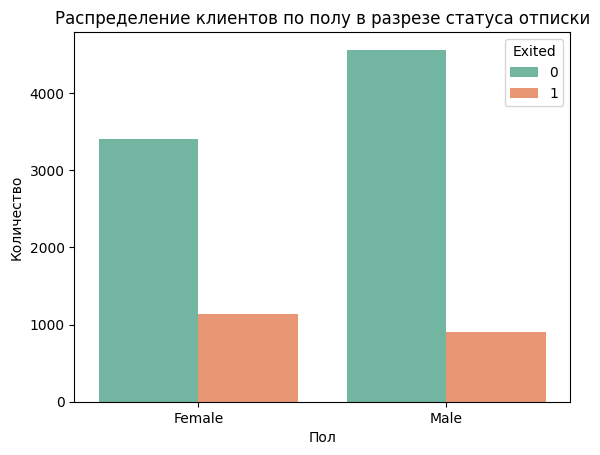

In [15]:
ax = sns.barplot(df.groupby(['Gender', 'Exited'], as_index=False).size(), x='Gender', y='size', hue='Exited')
ax.set_xlabel('Пол')
ax.set_ylabel('Количество')
ax.set_title('Распределение клиентов по полу в разрезе статуса отписки')

plt.show()

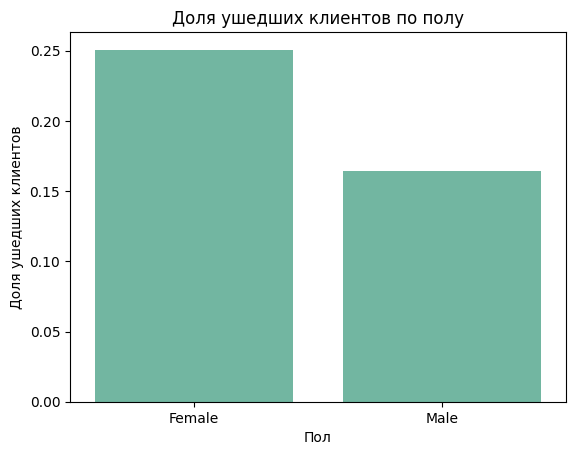

In [16]:
ax = sns.barplot(df.groupby(['Gender'], as_index=False).agg(Exited=('Exited', 'mean')), x='Gender', y='Exited')
ax.set_xlabel('Пол')
ax.set_ylabel('Доля ушедших клиентов')
ax.set_title('Доля ушедших клиентов по полу')

plt.show()

### Выводы

Обнаружена **статистически значимая разница** в доле ушедших клиентов среди женщин и мужчин. Женщины отказываются от банковских услуг чаще. Банку стоит выяснить причины и адаптировать продукт для женщин.

### Гипотеза №2

**Нулевая гипотеза ($H_0$):** Связь между полом и оттоком одинакова во всех странах

**Альтернативная гипотеза ($H_1$):** Связь между полом и оттоком различается в зависимости от страны

* Предпосылки. Влияние пола на отток может отличаться из-за культурных особенностей страны. Например, в религиозных странах женщины меньше работают и распространены патриархальные семьи, что может сказаться на пользовании банковскими услгуами

* Способ проверки гипотезы: логистическая регрессия с взаимодействием

* Уровень значимости: 0.05

In [17]:
model = smf.logit("Exited ~ C(Gender) * C(Geography)", data=df).fit()

Optimization terminated successfully.
         Current function value: 0.486031
         Iterations 6


In [18]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 Exited   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9994
Method:                           MLE   Df Model:                            5
Date:                Mon, 05 May 2025   Pseudo R-squ.:                 0.03849
Time:                        17:25:15   Log-Likelihood:                -4860.3
converged:                       True   LL-Null:                       -5054.9
Covariance Type:            nonrobust   LLR p-value:                 6.399e-82
=============================================================================================================
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                    -1.3649      0.052    -26.126      0.000      -1.467      -1.262
C(Gender)[T.Male]                            -0.5617      0.077     -7.250      0.000      -0.714      -0.410
C(Geography)[T.Germany]                       0.8563      0.079     10.785      0.000       0.701       1.012
C(Geography)[T.Spain]                         0.0527      0.091      0.581      0.561      -0.125       0.230
C(Gender)[T.Male]:C(Geography)[T.Germany]     0.1164      0.116      1.007      0.314      -0.110       0.343
C(Gender)[T.Male]:C(Geography)[T.Spain]      -0.0172      0.133     -0.129      0.897      -0.279       0.244
=============================================================================================================
"""

### Выводы

Статистически значимого взаимодействия пола и страны **не обнаружено** (p_value = 0.314 и p_value = 0.897 при принятом уровне значимости 0.05)

## Смолкина С.

### Гипотеза №1

**Нулевая гипотеза ($H_0$):** Средний возраст клиентов, которые ушли, равен среднему возрасту клиентов, которые остались.

**Альтернативная гипотеза ($H_1$):** Средний возраст клиентов, которые ушли, отличается от среднего возраста тех, кто остался.

* Используем: t-test (две независимые выборки - клиенты, которые ушли (Exited = 1) и клиенты, которые остались (Exited = 0)

In [20]:
import pandas as pd
from scipy.stats import ttest_ind
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [21]:
age_exited = df[df['Exited'] == 1]['Age']
age_not_exited = df[df['Exited'] == 0]['Age']

In [22]:
t_stat, p_value = ttest_ind(age_exited, age_not_exited, equal_var=False)

print(f"T-статистика: {t_stat:.3f}")
print(f"P-значение: {p_value:.5f}")

T-статистика: 30.419
P-значение: 0.00000


In [23]:
alpha = 0.05
if p_value < alpha:
    print("Отклоняем нулевую гипотезу: средние возраста различаются.")
else:
    print("Не удалось отклонить нулевую гипотезу: статистически значимой разницы в возрасте нет.")

Отклоняем нулевую гипотезу: средние возраста различаются.


### Гипотеза №2

**Нулевая гипотеза ($H_0$):** Отток клиентов не зависит от возраста и кредитного скора.

**Альтернативная гипотеза ($H_1$):** Отток клиентов зависит от возраста и/или кредитного скора.

* Используем: Логистическая регрессия (наиболее подходящая проверка, тк Exited бинарная переменная, а предикторы количественные)

In [24]:
X = df[['Age', 'CreditScore']]
X = sm.add_constant(X)

In [25]:
y = df['Exited']

In [27]:
model = sm.Logit(y, X).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.467164
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 Exited   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9997
Method:                           MLE   Df Model:                            2
Date:                Mon, 05 May 2025   Pseudo R-squ.:                 0.07582
Time:                        17:28:49   Log-Likelihood:                -4671.6
converged:                       True   LL-Null:                       -5054.9
Covariance Type:            nonrobust   LLR p-value:                3.594e-167
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -3.4457      0.200    -17.198      0.000      -3.838      -3.053
Age             0.0630      0.002     26.629      0.000       0.058       0.068
CreditScore    -0.0007      0.000     -2.788      0.005      -0.001      -0.000
===============================================================================
"""

In [28]:
age_range = np.linspace(df['Age'].min(), df['Age'].max(), 100)
credit_range = np.linspace(df['CreditScore'].min(), df['CreditScore'].max(), 100)
age_grid, credit_grid = np.meshgrid(age_range, credit_range)

In [29]:
age_flat = age_grid.ravel()
credit_flat = credit_grid.ravel()

In [30]:
X_pred = pd.DataFrame({
    'const': 1,
    'Age': age_flat,
    'CreditScore': credit_flat
})

In [31]:
y_pred_prob = model.predict(X_pred)

In [32]:
prob_df = pd.DataFrame({
    'Age': age_flat,
    'CreditScore': credit_flat,
    'Churn_Probability': y_pred_prob
})

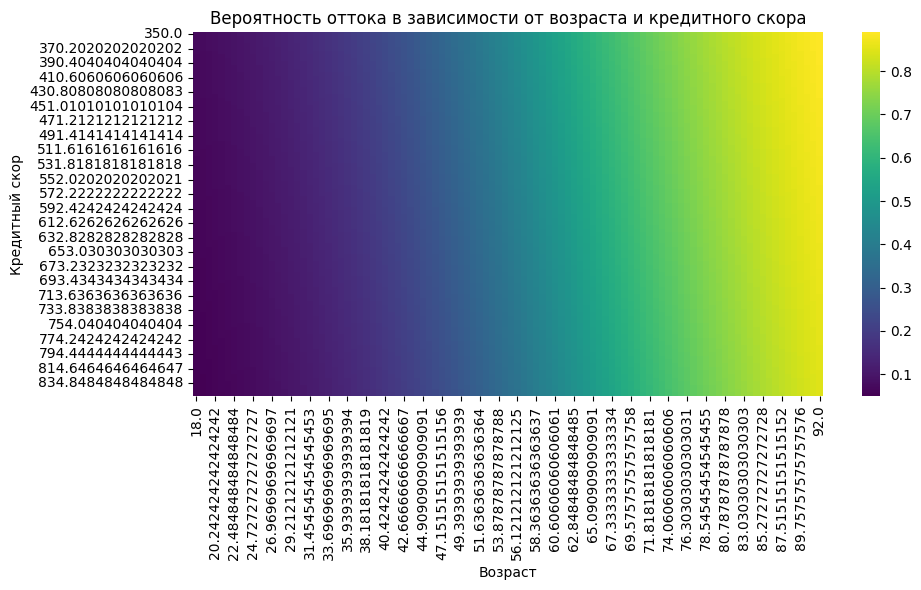

In [33]:
plt.figure(figsize=(10, 6))
pivot_table = prob_df.pivot_table(values='Churn_Probability', index='CreditScore', columns='Age')
sns.heatmap(pivot_table, cmap='viridis')
plt.title('Вероятность оттока в зависимости от возраста и кредитного скора')
plt.xlabel('Возраст')
plt.ylabel('Кредитный скор')
plt.tight_layout()
plt.show()

### Выводы

1. Вероятность оттока увеличивается с возрастом — ось X, цвета становятся ярче

2. При более высоком кредитном скоре (ось Y), отток в целом ниже, особенно у молодых клиентов

## Иванов Н.

### Гипотеза №1

**Нулевая гипотеза ($H_0$):** Срок сотрудничества не вступает в зависимость с оттоком

**Альтернативная гипотеза ($H_1$):** Клиенты с небольшим сроком сотрудничества (Tenure < 2 лет) могут чаще уходить

* Предпосылки: у клиентов, кто недавно пользуется услугами еще не сформировалась лояльность к банку.

* Способ проверки гипотезы: хи-квадрат тест на независимость

* Уровень значимости: 0.05

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportions_ztest

In [4]:
# Создание бинарной переменной для Tenure
df['Tenure_Group'] = np.where(df['Tenure'] < 2, 'Less than 2', '2 or more')

In [5]:
# Таблица сопряженности
contingency_table = pd.crosstab(df['Tenure_Group'], df['Exited'])
print("Таблица сопряженности:")
print(contingency_table)

Таблица сопряженности:
Exited           0     1
Tenure_Group            
2 or more     6842  1710
Less than 2   1121   327


In [6]:
# Хи-квадрат тест
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Результаты хи-квадрат теста: p-value = {p_value:.4f}")

Результаты хи-квадрат теста: p-value = 0.0260


In [9]:
# Z-тест для пропорций
count = np.array([contingency_table.loc['Less than 2', 1], contingency_table.loc['2 or more', 1]])
nobs = np.array([contingency_table.loc['Less than 2'].sum(), contingency_table.loc['2 or more'].sum()])
z_stat, p_val = proportions_ztest(count, nobs)
print(f"Результаты z-теста: p-value = {p_val:.4f}")

Результаты z-теста: p-value = 0.0238


In [10]:
# Доли оттока
p_less_than_2 = count[0] / nobs[0]
p_2_or_more = count[1] / nobs[1]
print(f"Доля оттока (Tenure < 2): {p_less_than_2:.4f}")
print(f"Доля оттока (Tenure >= 2): {p_2_or_more:.4f}")

Доля оттока (Tenure < 2): 0.2258
Доля оттока (Tenure >= 2): 0.2000


### Выводы

1. Статистическая значимость различий: p-value = 0.026 (< 0.05) → Разница в оттоке статистически значима.
  * Это означает, что мы отвергаем нулевую гипотезу (о том, что срок сотрудничества не влияет на отток) и принимаем альтернативную: клиенты с небольшим сроком сотрудничества (Tenure < 2 лет) уходят достоверно чаще, чем клиенты с более длительным сроком.

2. Размер эффекта:
  * Доля оттока в группе Tenure < 2 лет: 22.58%
  * Доля оттока в группе Tenure ≥ 2 лет: 20.00%

  Абсолютная разница: 2.58 процентных пункта

3. Возможные причины:

  * Недостаточная адаптация (клиенты не успели "привыкнуть" к сервису).

  * Ошибки в onboarding-процессе (например, сложный интерфейс, отсутствие персональной поддержки).

  * Маркетинговые ожидания не совпали с реальностью (например, клиентов привлекли агрессивными акциями, но сервис их разочаровал).

### Гипотеза №2

**Нулевая гипотеза ($H_0$):** Баланс не вступает в зависимость с оттоком

**Альтернативная гипотеза ($H_1$):** Клиенты с высоким балансом уходят чаще

* Предпосылки:клиенты могут себя вести по разному в зависимости от баланса

* Способ проверки гипотезы: Двухвыборочный t-тест (независимый t-тест) и U-теста Манна-Уитни

* Уровень значимости: 0.05

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [41]:
# Разделение данных на две группы: ушедшие и оставшиеся клиенты
exited_balance = df[df['Exited'] == 1]['Balance']
not_exited_balance = df[df['Exited'] == 0]['Balance']

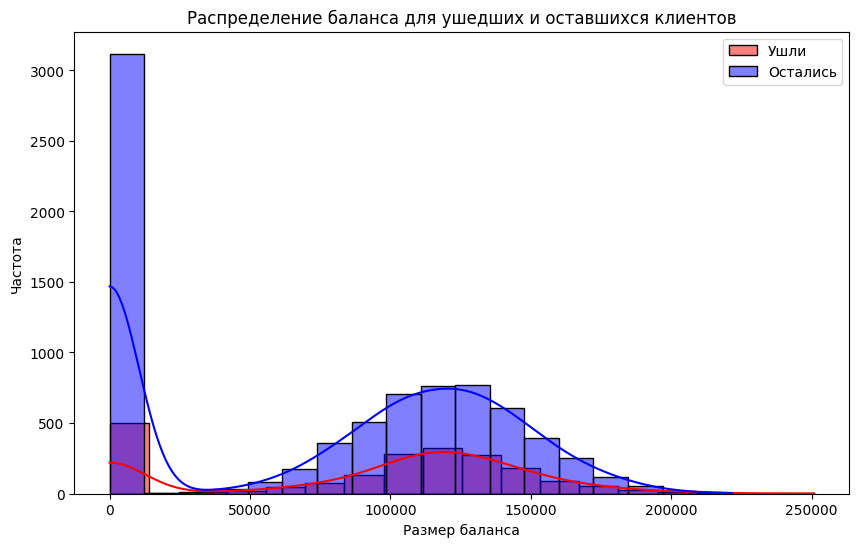

In [43]:
# Визуализация распределения баланса
plt.figure(figsize=(10, 6))
sns.histplot(exited_balance, color='red', label='Ушли', kde=True)
sns.histplot(not_exited_balance, color='blue', label='Остались', kde=True)
plt.title('Распределение баланса для ушедших и оставшихся клиентов')
plt.xlabel('Размер баланса')
plt.ylabel('Частота')
plt.legend()
plt.show()

In [44]:
# Двухвыборочный t-тест (предполагаем, что дисперсии не равны)
t_stat, p_value = stats.ttest_ind(exited_balance, not_exited_balance, equal_var=False)
print("Результаты двухвыборочного t-теста:")
print("t-статистика:", t_stat)
print("p-value:", p_value)

Результаты двухвыборочного t-теста:
t-статистика: 12.471280320050688
p-value: 6.318663518527974e-35


In [74]:
# U-тест Манна-Уитни (непараметрический аналог)
u_stat, p_value_mann = stats.mannwhitneyu(exited_balance, not_exited_balance)
print("Результаты U-теста Манна-Уитни:")
print("U-статистика:", u_stat)
print("p-value:", p_value_mann)

Результаты U-теста Манна-Уитни:
U-статистика: 9371186.5
p-value: 1.1158399379149222e-28


### Выводы

Исходя из результатов двухвыборочного t-теста и U-теста Манна-Уитни, мы **отвергаем нулевую гипотезу** о том, что баланс не влияет на отток клиентов.

Это решение основано на очень низких значениях p-value (6.32e-35 и 1.11e-28), которые значительно меньше стандартного уровня значимости 0.05.

Эти результаты указывают на **наличие статистически значимой зависимости**: клиенты с высоким балансом действительно имеют более высокий риск ухода.

## Никитюк М.

### Гипотеза №1

**Нулевая гипотеза ($H_0$):** Клиенты в разных географических регионах (Франция, Испания, Германия) имеют одинаковую долю оттока.

**Альтернативная гипотеза ($H_1$):** География влияет на уровень оттока

* Предпосылки: место проживания клиентов имеет свой вклад в причину ухода или продолжение пользованием услугами банка. Например, некоторым регионам может предоставляться ряд акций, недоступных для других жителей.

* Критерий проверки: критерий независимости Хи-квадрат

In [46]:
contingency_table = pd.crosstab(df['Geography'], df['Exited'])

In [47]:
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Статистика Хи-квадрат: {chi2_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Статистика Хи-квадрат: 301.2553
P-value: 0.0000


In [49]:
print("Таблица сопряженности:")
contingency_table

Таблица сопряженности:


Exited,0,1
Geography,,
France,4204,810
Germany,1695,814
Spain,2064,413


In [50]:
print("Ожидаемые частоты:")
pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)

Ожидаемые частоты:


Exited,0,1
Geography,,
France,3992.6482,1021.3518
Germany,1997.9167,511.0833
Spain,1972.4351,504.5649


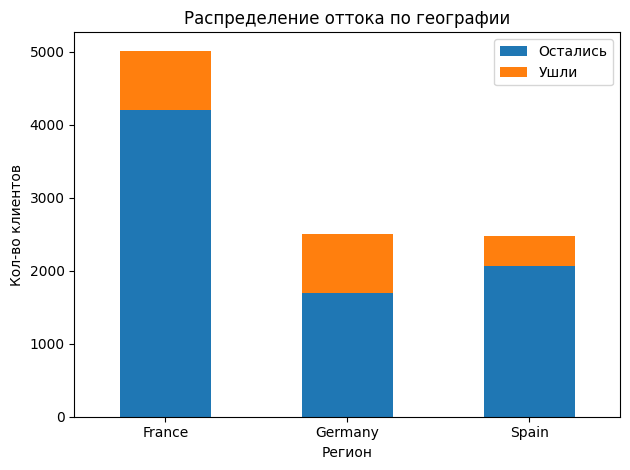

In [51]:
contingency_table.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'])
plt.title('Распределение оттока по географии')
plt.xlabel('Регион')
plt.ylabel('Кол-во клиентов')
plt.legend(['Остались', 'Ушли'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [61]:
df.pivot_table(values='Exited', index='Geography', aggfunc='mean') * 100

,Exited
Geography,
France,16.154767
Germany,32.443204
Spain,16.673395


In [53]:
alpha = 0.05
if p_value < alpha:
    print("Отвергаем нулевую гипотезу (H0). Есть основания полагать, что география влияет на уровень оттока.")
else:
    print("Не удается отклонить нулевую гипотезу (H0). Нет оснований говорить, что география влияет на уровень оттока.")

Отвергаем нулевую гипотезу (H0). Есть основания полагать, что география влияет на уровень оттока.


### Выводы

* Показатели оттока клиентов существенно различаются в странах: например, в Германии самый высокий уровень оттока (814/2509 ≈ 32,4%) по сравнению с Францией (810/5014 ≈ 16,2%) и Испанией (413/2477 ≈ 16,7%), как видно из таблицы непредвиденных расходов.

* Это наглядно видно на `bar chart'е`: большая доля оттока характерна для Германии по сравнению с другими регионами.

* Есть основания полагать, что банк сосредоточен больше на своих Французских клиентах.

### Гипотеза №2

**Нулевая гипотеза ($H_0$):** Средняя зарплата у ушедших и оставшихся клиентов одинаковая

**Альтернаятивная гипотеза ($H_1$):** Средняя зарплата у ушедших и оставшихся клиентов различается.

* Предпосылки: некоторые банки стремятся поощрять более платежеспособных клиентов, которые хранят бо́льшую часть своих средств/накоплений в этих банках.

* Критерий проверки: t-тест независимых выборок

In [62]:
churned = df[df['Exited'] == 1]['EstimatedSalary']
retained = df[df['Exited'] == 0]['EstimatedSalary']

In [63]:
t_stat, p_value = stats.ttest_ind(churned, retained, equal_var=True)

In [64]:
mean_churned = churned.mean()
mean_retained = retained.mean()
std_churned = churned.std()
std_retained = retained.std()

In [65]:
print(f"Статистика Стьюдента: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

Статистика Стьюдента: 1.2097
p-value: 0.2264


In [66]:
print(f"Средняя з/п ушедших клиентов: {mean_churned:.2f}")
print(f"Средняя з/п оставшихся клиентов: {mean_retained:.2f}")

Средняя з/п ушедших клиентов: 101465.68
Средняя з/п оставшихся клиентов: 99738.39


<ipython-input-72-a3709fd06294>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='EstimatedSalary', data=df, palette=['#1f77b4', '#ff7f0e'])


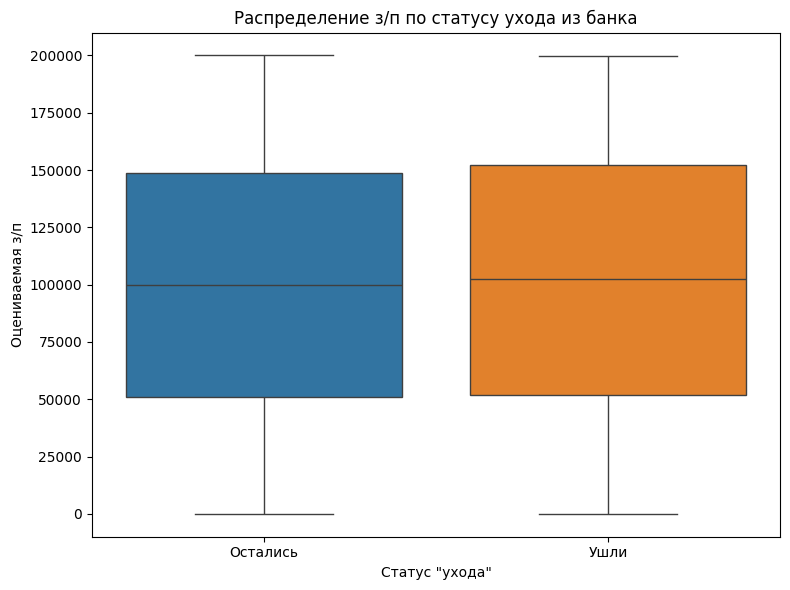

In [72]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Exited', y='EstimatedSalary', data=df, palette=['#1f77b4', '#ff7f0e'])
plt.title('Распределение з/п по статусу ухода из банка')
plt.xlabel('Статус "ухода"')
plt.ylabel('Оцениваемая з/п')
plt.xticks([0, 1], ['Остались', 'Ушли'])
plt.tight_layout()

plt.show()

In [70]:
alpha = 0.05
if p_value < alpha:
    print("Отвергаем нулевую гипотезу (H0). Есть признаки того, что средняя зарплата ушедних и оставшихся клиентов различается.")
else:
    print("Не удается отклонить нулевую гипотезу (H0). Нет причин утверждать, что средняя зарплата ушедних и оставшихся клиентов отличается.")

Не удается отклонить нулевую гипотезу (H0). Нет причин утверждать, что средняя зарплата ушедних и оставшихся клиентов отличается.


### Выводы

* Средние зарплаты ушедних и оставшихся клиентов существенно не различаются.

* Средние зарплаты (101465.68 у ушедних и 99738.39 оставшихся) довольно близки, а высокое значение p предполагает, что любая наблюдаемая разница может быть вызвана случайными колебаниями.

* Можно сделать вывод, что средняя зарплата не является причиной прекращения пользованием услугами банка.